## Uniform weights

$$K = \frac{1}{9} \begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}$$

Text(0.5, 1.0, 'blurred with 7x7 filter')

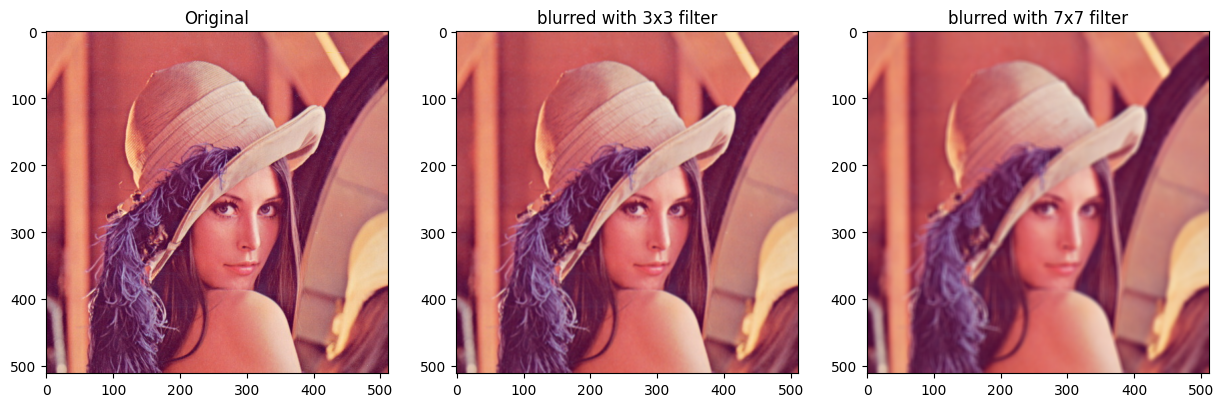

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('lena.jpg')

# Creating our 3 x 3 kernel
kernel_3x3 = np.ones((3, 3), np.float32) / 9

# We use the cv2.fitler2D to conovlve the kernal with an image
blurred = cv2.filter2D(image, -1, kernel_3x3)


# Creating our 7 x 7 kernel
kernel_7x7 = np.ones((7, 7), np.float32) / 49

blurred2 = cv2.filter2D(image, -1, kernel_7x7)

plt.figure(figsize=[15,5])
plt.subplot(131);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(132);plt.imshow(blurred[...,::-1]);plt.title("blurred with 3x3 filter")
plt.subplot(133);plt.imshow(blurred2[...,::-1]);plt.title("blurred with 7x7 filter")

## Non-uniform weights

If only σx (sigmaX) is specified, then σy (sigmaY) is automatically set equal to σx.

If both σx and σy are set to 0, their values are automatically calculated based on the kernel size.

Gaussian blurring is highly effective for removing Gaussian noise from an image because it performs weighted averaging, giving more importance to pixels near the center of the kernel.

## Non-Uniform (Gaussian) Filter Equation

A Gaussian filter is a **non-uniform filter**, meaning its weights are not equal.  
The weights follow a Gaussian (normal) distribution.

---

### 2D Gaussian Filter Equation

$$
G(x, y) = \frac{1}{2\pi \sigma_x \sigma_y}
\exp \left(
-\left(
\frac{x^2}{2\sigma_x^2} + \frac{y^2}{2\sigma_y^2}
\right)
\right)
$$

---

### Where:

- \( x, y \) → spatial coordinates relative to the kernel center  
- \( \sigma_x \) → standard deviation in the x-direction  
- \( \sigma_y \) → standard deviation in the y-direction  
- \( \exp \) → exponential function  

---

### Special Case (Isotropic Gaussian Filter)

If:

$$
\sigma_x = \sigma_y = \sigma
$$

Then the equation simplifies to:

$$
G(x, y) = \frac{1}{2\pi \sigma^2}
\exp \left(
-\frac{x^2 + y^2}{2\sigma^2}
\right)
$$

---

### Uniform (Mean) Filter for Comparison

A uniform filter assigns equal weights to all kernel elements:

$$
H(x, y) = \frac{1}{M \times N}
$$

---

### Key Difference

- **Uniform filter** → All weights are equal  
- **Gaussian filter** → Center pixels have higher weights, distant pixels have lower weights  
- Gaussian filtering is more effective for removing Gaussian noise while preserving image structures.

Text(0.5, 1.0, 'After bilateral filter')

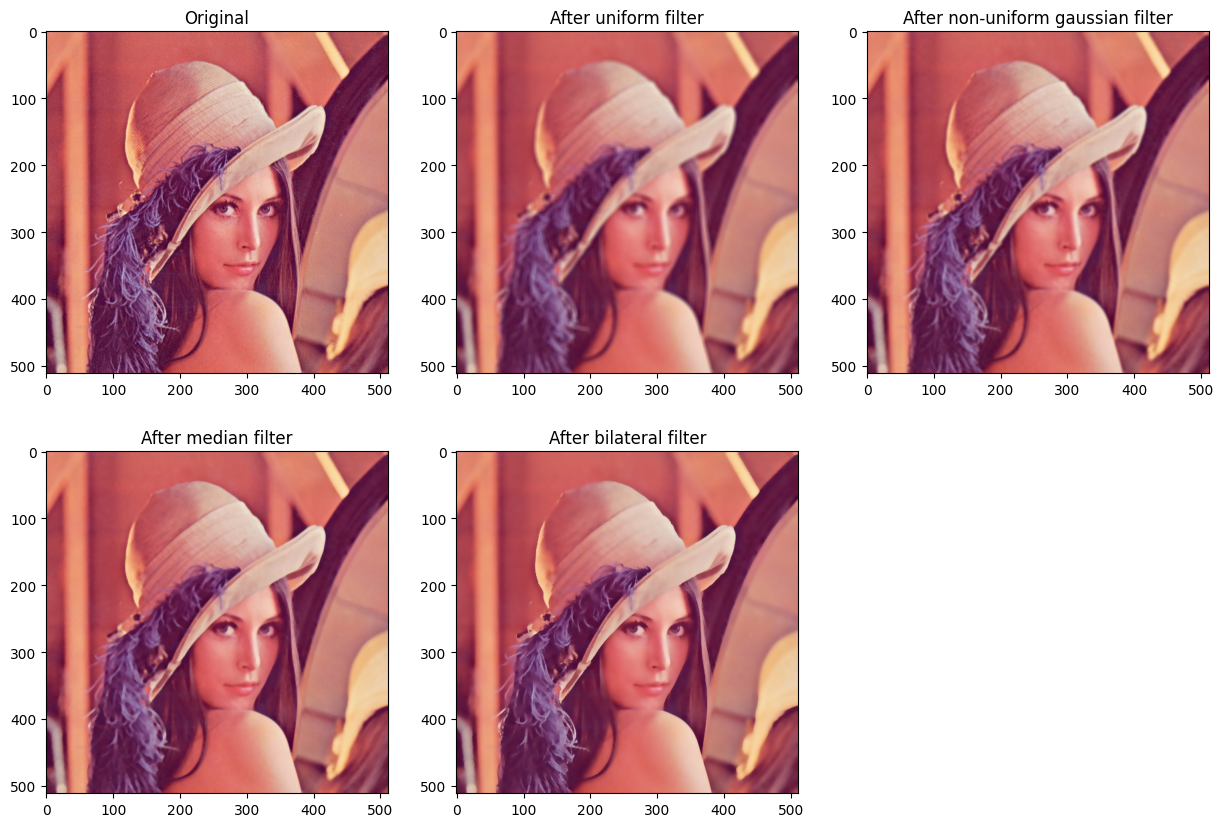

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('lena.jpg')

# Averaging done by convolving the image with a normalized box filter.
# This takes the pixels under the box and replaces the central element
# Box size needs to odd and positive
blur = cv2.blur(image, (7,7))

# Instead of box filter, gaussian kernel
gaussian = cv2.GaussianBlur(image, (7,7), 0)

# Takes median of all the pixels under kernel area and central
# element is replaced with this median value
median = cv2.medianBlur(image, 5)

# Bilateral is very effective in noise removal while keeping edges sharp
bilateral = cv2.bilateralFilter(image, 9, 75, 75)


plt.figure(figsize=[15,10])
plt.subplot(231);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(232);plt.imshow(blur[...,::-1]);plt.title("After uniform filter")
plt.subplot(233);plt.imshow(gaussian[...,::-1]);plt.title("After non-uniform gaussian filter")
plt.subplot(234);plt.imshow(median[...,::-1]);plt.title("After median filter")
plt.subplot(235);plt.imshow(bilateral[...,::-1]);plt.title("After bilateral filter")

Text(0.5, 1.0, 'Gaussian filter, sigma=5')

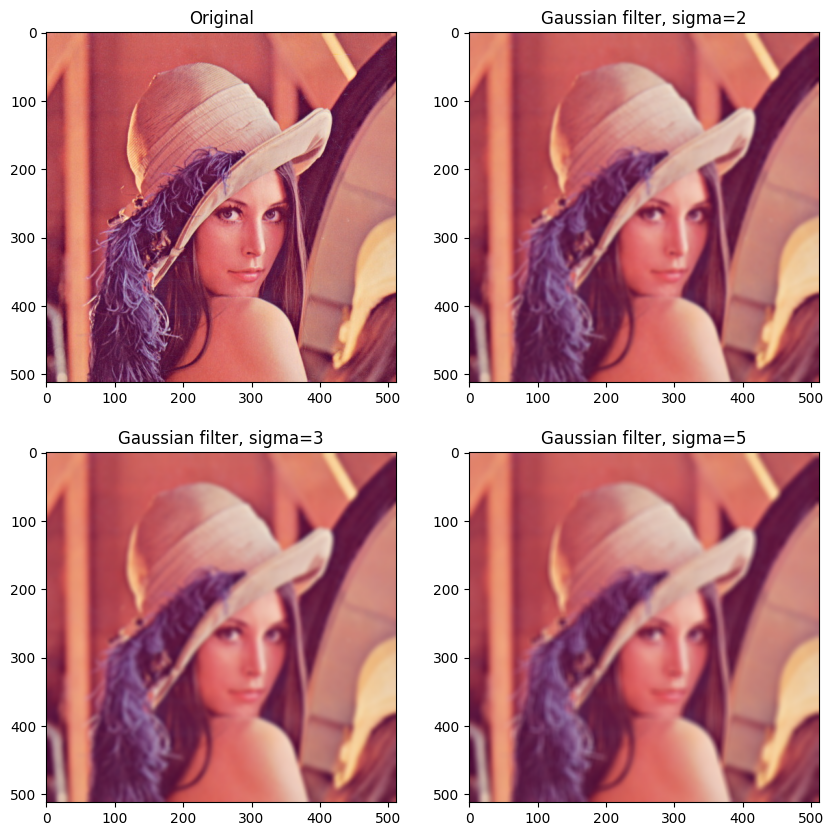

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('lena.jpg')

gaussian2 = cv2.GaussianBlur(image, (11,11), 2)
gaussian3 = cv2.GaussianBlur(image, (11,11), 3)
gaussian5 = cv2.GaussianBlur(image, (11,11), 5)

plt.figure(figsize=[10,10])
plt.subplot(221);plt.imshow(image[...,::-1]);plt.title("Original");
plt.subplot(222);plt.imshow(gaussian2[...,::-1]);plt.title("Gaussian filter, sigma=2")
plt.subplot(223);plt.imshow(gaussian3[...,::-1]);plt.title("Gaussian filter, sigma=3")
plt.subplot(224);plt.imshow(gaussian5[...,::-1]);plt.title("Gaussian filter, sigma=5")

## Image De-noising – Non-Local Means Denoising (NLM)

Non-Local Means (NLM) is an advanced image de-noising algorithm that removes noise
while preserving edges and fine details.

Unlike local filters (e.g., Gaussian filter) that average neighboring pixels,
NLM computes the denoised value of a pixel by taking a weighted average of
all pixels in the image based on similarity.

---

### Core Idea

Instead of averaging only nearby pixels, NLM:

- Compares small patches around pixels
- Finds similar patches across the entire image
- Assigns higher weights to more similar patches
- Computes a weighted average

---

### Mathematical Formulation

For a noisy image \( I \), the denoised pixel value at location \( i \) is:

$$
NL[I](i) = \sum_{j \in \Omega} w(i,j) \, I(j)
$$

Where:

- \( \Omega \) → search window (possibly entire image)
- \( w(i,j) \) → similarity-based weight
- \( I(j) \) → intensity at pixel \( j \)

---

### Weight Function

$$
w(i,j) = \frac{1}{Z(i)}
\exp \left(
-\frac{ \| P_i - P_j \|^2 }{h^2}
\right)
$$

Where:

- \( P_i \), \( P_j \) → patches centered at pixels \( i \) and \( j \)
- \( \| P_i - P_j \|^2 \) → squared Euclidean distance between patches
- \( h \) → filtering parameter (controls smoothing strength)
- \( Z(i) \) → normalization factor

$$
Z(i) = \sum_{j \in \Omega}
\exp \left(
-\frac{ \| P_i - P_j \|^2 }{h^2}
\right)
$$

---

### Key Parameters

| Parameter | Effect |
|-----------|--------|
| `h` | Larger → stronger smoothing |
| Patch size | Larger → more structural comparison |
| Search window size | Larger → better denoising but slower computation |

---

### Advantages

- Excellent edge preservation  
- Effective for Gaussian noise  
- Maintains fine textures  

---

### Disadvantages

- Computationally expensive  
- Slower than local filters  
- Requires careful parameter tuning  

Text(0.5, 1.0, 'After NLM Denoising')

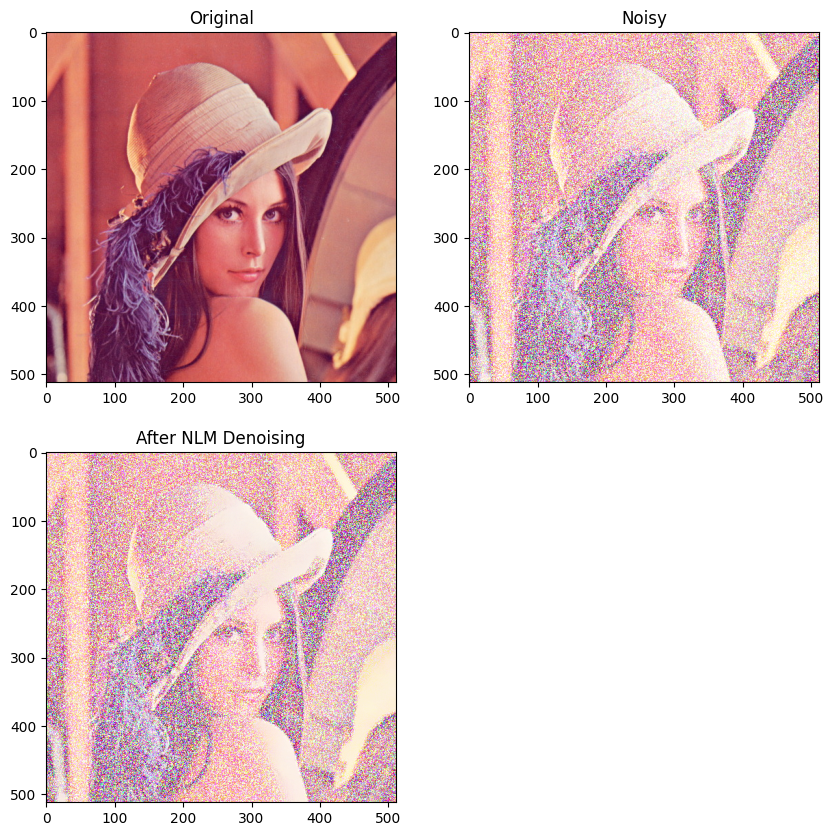

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('lena.jpg')

# Add Gaussian noise to simulate a noisy image
noise = np.random.normal(0, 30, image.shape).astype(np.uint8)
noisy = cv2.add(image, noise)

# Parameters, after None are - the filter strength 'h' (5-10 is a good range)
# Next is hForColorComponents, set as same value as h again
dst = cv2.fastNlMeansDenoisingColored(noisy, None, 6, 6, 7, 21)

plt.figure(figsize=[10,10])
plt.subplot(221);plt.imshow(image[...,::-1]);plt.title('Original')
plt.subplot(222);plt.imshow(noisy[...,::-1]);plt.title('Noisy')
plt.subplot(223);plt.imshow(dst[...,::-1]);plt.title('After NLM Denoising')


**There are 4 variations of Non-Local Means Denoising:**

- cv2.fastNlMeansDenoising() - works with a single grayscale images
- cv2.fastNlMeansDenoisingColored() - works with a color image.
- cv2.fastNlMeansDenoisingMulti() - works with image sequence captured in short period of time (grayscale images)
- cv2.fastNlMeansDenoisingColoredMulti() - same as above, but for color images.

https://docs.opencv.org/3.3.1/d5/d69/tutorial_py_non_local_means.html

## Image Sharpening

Image sharpening enhances edges and fine details by emphasizing high-frequency components in an image.

Sharpening increases contrast at intensity transitions, making the image appear clearer and more defined.

---

## 1️⃣ Unsharp Masking (Most Common Method)

Sharpening is often performed using **Unsharp Masking**:

### Step 1: Blur the image
$$
I_{blur} = I * G
$$

### Step 2: Extract details (high-frequency components)
$$
Mask = I - I_{blur}
$$

### Step 3: Add scaled details back to the image
$$
I_{sharp} = I + k \cdot (I - I_{blur})
$$

Where:

- \( I \) → original image  
- \( G \) → Gaussian kernel  
- \( k \) → sharpening factor  
- \( * \) → convolution  

---

### Effect of Parameter \( k \)

| k Value | Effect |
|----------|--------|
| \( k = 0 \) | No sharpening |
| \( 0 < k < 1 \) | Mild sharpening |
| \( k = 1 \) | Standard sharpening |
| \( k > 1 \) | Strong sharpening |
| Large k | Over-sharpening & noise amplification |

---

## 2️⃣ Laplacian-Based Sharpening

Another approach uses the Laplacian operator:

$$
I_{sharp} = I - \lambda \nabla^2 I
$$

Where:

- \( \nabla^2 I \) → Laplacian (second derivative)
- \( \lambda \) → sharpening strength

Common Laplacian kernel:

$$
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

---

## Why Sharpening Works

- Edges correspond to rapid intensity changes.
- High-pass filtering enhances these rapid changes.
- The result increases local contrast at boundaries.

---

## ⚠️ Important Note

Sharpening also amplifies noise.  
It is often recommended to apply mild smoothing (e.g., Gaussian blur) before sharpening.

[[-0.11111111 -0.11111111 -0.11111111]
 [-0.11111111  1.88888889 -0.11111111]
 [-0.11111111 -0.11111111 -0.11111111]]


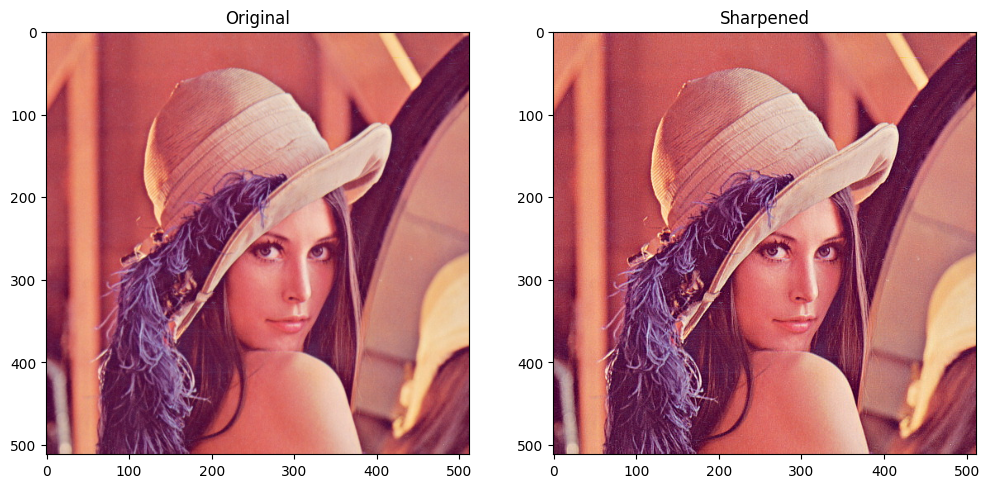

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('lena.jpg')

kernel1 = np.array([[0,0,0],
                              [0,2,0],
                              [0,0,0]])

kernel2 = 1/9*np.array([[1,1,1],
                              [1,1,1],
                              [1,1,1]])

final_kernel = kernel1-kernel2
# applying different kernels to the input image
sharpened = cv2.filter2D(image, -1, final_kernel)

plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(122);plt.imshow(sharpened[...,::-1]);plt.title("Sharpened")
print(final_kernel)

Text(0.5, 1.0, 'Sharpened')

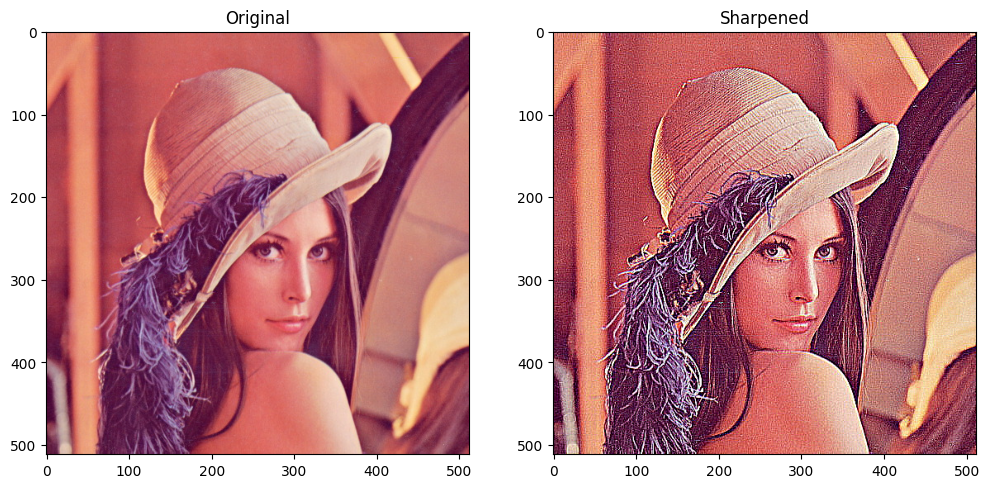

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('lena.jpg')

kernel_sharpening = np.array([[-1,-1,-1],
                              [-1,9,-1],
                              [-1,-1,-1]])

# applying different kernels to the input image
sharpened = cv2.filter2D(image, -1, kernel_sharpening)

plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(122);plt.imshow(sharpened[...,::-1]);plt.title("Sharpened")

## Edge Detection and Image Gradient

Edge detection is a fundamental technique in image processing that identifies points in an image where intensity changes sharply.  
These points often correspond to object boundaries, textures, or important features.

---

### 1️⃣ Image Gradient

The **gradient** measures the rate of change of intensity at each pixel.  
It is a vector with **magnitude** and **direction**:

$$
\nabla I =
\begin{bmatrix}
G_x \\
G_y
\end{bmatrix}
=
\begin{bmatrix}
\frac{\partial I}{\partial x} \\
\frac{\partial I}{\partial y}
\end{bmatrix}
$$

- \(G_x, G_y\) → gradients along x and y axes  
- **Gradient magnitude**:  
$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}
$$  
- **Gradient direction**:  
$$
\theta = \arctan\left(\frac{G_y}{G_x}\right)
$$

---

### 2️⃣ Common Edge Detection Operators

| Operator | Description |
|----------|------------|
| **Sobel** | Approximates gradient using convolution with Sobel kernels. |
| **Prewitt** | Similar to Sobel but with uniform weights. |
| **Roberts** | Uses 2×2 kernels for diagonal gradients. |
| **Canny** | Multi-step algorithm: smoothing, gradient, non-maximum suppression, hysteresis. |

---

### 3️⃣ Steps in Edge Detection

1. **Smoothing** – Reduce noise using Gaussian blur  
2. **Gradient computation** – Calculate magnitude & direction  
3. **Non-maximum suppression** – Thin edges  
4. **Thresholding / Hysteresis** – Select significant edges

---

### Key Notes

- Edges correspond to **high gradient magnitudes**  
- Gradient-based methods are sensitive to noise → smoothing is important  
- Used in **feature extraction, object detection, and image analysis**

```cv2.filter2D(src, ddepth, kernel)```

The function does actually compute ``correlation``, ``not the convolution``

## Function to Check Matrix Range and Type

The following Python function takes a matrix (2D list or NumPy array) and prints:

- The **minimum and maximum values** (range)  
- The **data type** of the matrix elements  

In [8]:
import numpy as np

def check_matrix_range(matrix):
    """
    Prints the range (min, max) and type of a matrix.

    Parameters:
    matrix : list of lists or numpy array
        Input matrix to be analyzed.
    """
    # Convert list of lists to NumPy array if needed
    mat = np.array(matrix)

    # Get min and max
    min_val = np.min(mat)
    max_val = np.max(mat)

    # Get data type
    dtype = mat.dtype

    print(f"Matrix type: {dtype}")
    print(f"Minimum value: {min_val}")
    print(f"Maximum value: {max_val}")
    print(f"Range: {min_val} to {max_val}")

# Example usage
matrix = [[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]

check_matrix_range(matrix)

Matrix type: int64
Minimum value: 1
Maximum value: 9
Range: 1 to 9


In [9]:
import numpy as np

def print_min_and_max(matrix):
    mat = np.array(matrix)
    print(f'Type: {mat.dtype}, Min: {mat.min():.4f}, Max: {mat.max():.4f}')


## Displaying Image Gradient with Fuzzy Brightness Variations

This technique visualizes the **gradient of an image** while accounting for **fuzzy changes in brightness**, rather than sharp intensity differences.  
It is particularly useful for highlighting edges in images with **gradual transitions** or **soft boundaries**.

---

### 1️⃣ Concept

- The **image gradient** measures the rate of intensity change at each pixel.  
- **Fuzzy brightness variations** map gradient magnitudes to a **soft scale** (0–1), emphasizing subtle intensity changes.  
- This reduces the effect of noise and enhances important structural information.

---

### 2️⃣ Fuzzy Gradient Computation

1. Compute the **gradient** (e.g., using Sobel operator):

$$
G_x = I * S_x, \quad G_y = I * S_y
$$

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}
$$

Where \(S_x\) and \(S_y\) are Sobel kernels in x and y directions.

2. Apply a **fuzzy membership function** to normalize the gradient:

$$
\mu(x, y) = \frac{|\nabla I(x, y)| - G_{\min}}{G_{\max} - G_{\min}}
$$

- \( \mu(x, y) \in [0, 1] \)  
- \( G_{\min}, G_{\max} \) → minimum and maximum gradient values  
- Highlights **soft edges** and subtle transitions.

---

### 3️⃣ Visualization

- Map fuzzy gradient values to **0–255** for display.  
- Use a colormap (grayscale or color) to show gradient strength.  
- Brighter regions → **stronger edges**  
- Darker regions → **weaker/fuzzy edges**



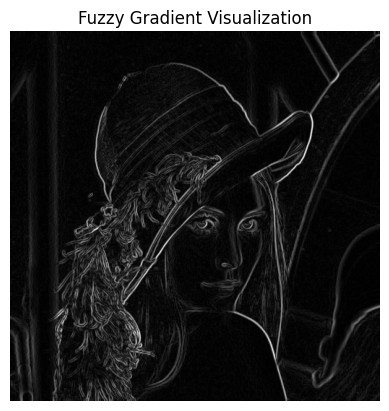

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

# Compute Sobel gradients
Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
grad_mag = np.sqrt(Gx**2 + Gy**2)

# Apply fuzzy normalization
Gmin, Gmax = grad_mag.min(), grad_mag.max()
fuzzy_grad = (grad_mag - Gmin) / (Gmax - Gmin)

# Display fuzzy gradient
plt.imshow(fuzzy_grad, cmap='gray')
plt.title('Fuzzy Gradient Visualization')
plt.axis('off')
plt.show()

Type: uint8, Min: 18.0000, Max: 248.0000
Type: uint8, Min: 0.0000, Max: 83.0000


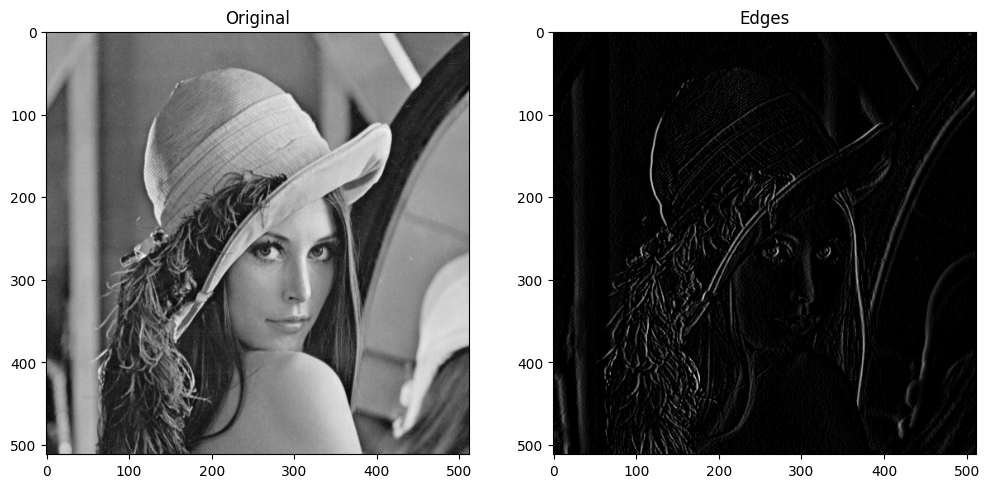

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('lena.jpg',0)

kernel = np.array([[0,0,0],
                   [-1/2,0,1/2],
                   [0,0,0]])


# Extract Sobl Edges
edges = cv2.filter2D(image, -1 , kernel)

plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(edges, cmap='gray');plt.title("Edges");

print_min_and_max(image)
print_min_and_max(edges)

## Displaying Image Gradient with Sudden Brightness Changes

This technique visualizes the **gradient of an image** focusing on **abrupt or sudden intensity changes**.  
It is ideal for detecting **sharp edges**, object boundaries, or high-contrast regions.

---

### 1️⃣ Concept

- **Gradient** measures the rate of intensity change at each pixel.  
- Sudden brightness changes correspond to **high gradient magnitudes**.  
- This approach emphasizes **strong edges** while ignoring small variations.

---

### 2️⃣ Gradient Computation

1. Compute gradients using operators like **Sobel, Prewitt, or Roberts**:

$$
G_x = I * S_x, \quad G_y = I * S_y
$$

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}
$$

Where \(S_x\) and \(S_y\) are convolution kernels along x and y directions.

2. Threshold the gradient (optional) to highlight **only strong edges**:

$$
Edge(x, y) =
\begin{cases}
1, & |\nabla I(x, y)| > T \\
0, & \text{otherwise}
\end{cases}
$$

- \(T\) → gradient magnitude threshold

---

### 3️⃣ Visualization

- Map gradient magnitudes to **0–255** intensity.  
- Brighter areas correspond to **sharp brightness changes**.  
- Dark regions indicate **flat or smooth areas**.

---



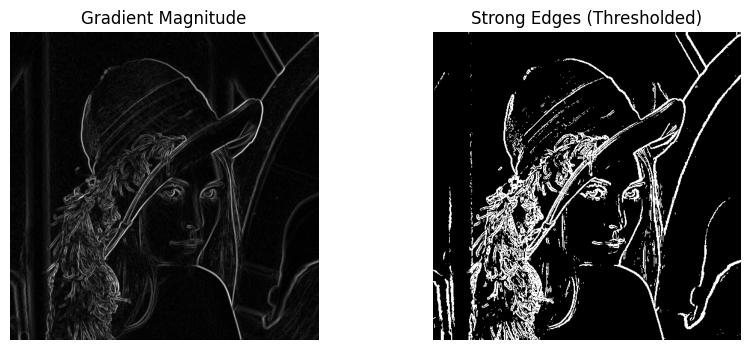

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

# Compute Sobel gradients
Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
grad_mag = np.sqrt(Gx**2 + Gy**2)

# Optional: Threshold to emphasize strong edges
T = 100  # Example threshold
edges = np.uint8((grad_mag > T) * 255)

# Display gradient
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(grad_mag, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Strong Edges (Thresholded)')
plt.axis('off')
plt.show()


Type: uint8, Min: 18.0000, Max: 248.0000
Type: uint8, Min: 0.0000, Max: 83.0000


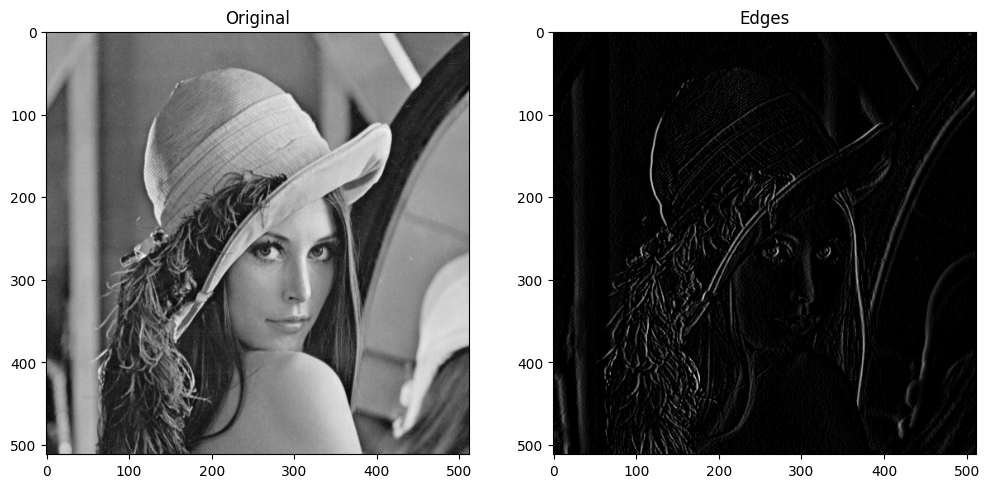

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('lena.jpg',0)

kernel = np.array([[0,0,0],
                   [-1/2,0,1/2],
                   [0,0,0]])


# Extract Sobl Edges
edges = cv2.filter2D(image, -1 , kernel)

plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(edges, cmap='gray');plt.title("Edges");

print_min_and_max(image)
print_min_and_max(edges)

## Displaying Negative Values of a Filtered Image using `filter2D`

The OpenCV function `cv2.filter2D()` applies a filter to an image.  
The **second parameter** (`ddepth`) controls the **output data type**.  
To **preserve negative values** from the filter, you must use a data type that supports negatives, such as `CV_16S` or `CV_32F`.


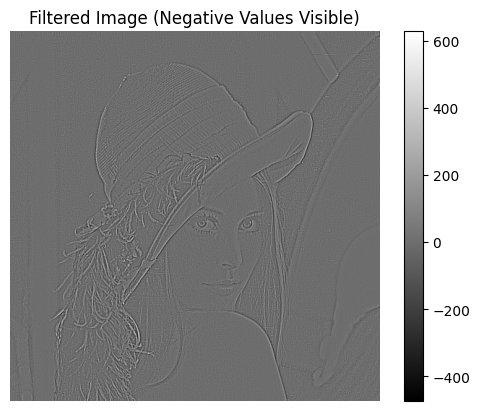

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

# Define a sample kernel (edge detection)
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

# Apply filter with 32-bit float output to preserve negative values
filtered = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=kernel)

# Display the filtered image with negative values visible
plt.imshow(filtered, cmap='gray')
plt.title('Filtered Image (Negative Values Visible)')
plt.colorbar()
plt.axis('off')
plt.show()

Type: uint8, Min: 18.0000, Max: 248.0000
Type: float64, Min: -90.5000, Max: 83.0000


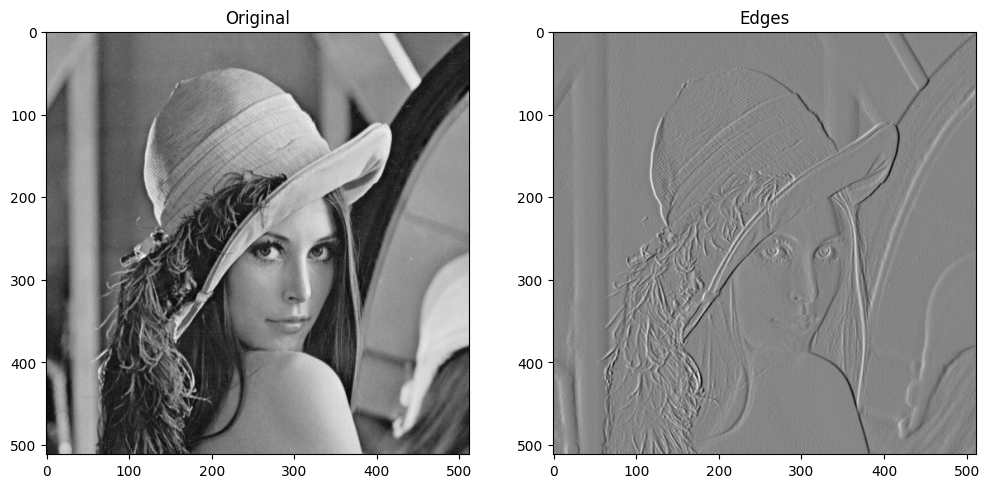

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('lena.jpg',0)

kernel = np.array([[0,0,0],
                   [-1/2,0,1/2],
                   [0,0,0]])


# Extract Sobl Edges
edges = cv2.filter2D(image, cv2.CV_64F , kernel)

plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(edges, cmap='gray');plt.title("Edges");

print_min_and_max(image)
print_min_and_max(edges)